
# Build processed TEC dataset

This notebook downloads daily IONEX/GIM files into temporary Colab storage, parses them, aggregates TEC values by predefined regions, and saves processed regional time series as CSV and Parquet.

The requested interval uses the project convention `[start, end)`: `START_DATE` is included and `END_DATE` is excluded. Raw IONEX files are not stored in Git or Google Drive.


In [1]:
from pathlib import Path
import sys
import os
import shutil
import gzip
import re
from datetime import date, datetime, timedelta
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

import numpy as np
import pandas as pd

In [2]:
IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # If the repo is cloned into /content/tec_agent_project
    PROJECT_ROOT = Path("/content/tec_agent_project")
    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/tec_agent_project")

else:
    # Local VS Code mode
    PROJECT_ROOT = Path.cwd()
    DRIVE_PROJECT_DIR = PROJECT_ROOT

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

TMP_DIR = Path("/content/tec_tmp") if IN_COLAB else PROJECT_ROOT / "data" / "cache" / "tec_tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = DRIVE_PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TMP_DIR:", TMP_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
PROJECT_ROOT: /content/tec_agent_project
TMP_DIR: /content/tec_tmp
PROCESSED_DIR: /content/drive/MyDrive/tec_agent_project/data/processed


In [3]:
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/ilyakosilov/tec_agent_project.git"
PROJECT_ROOT = Path("/content/tec_agent_project")

if not PROJECT_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "origin", "main"], check=True)

os.chdir(PROJECT_ROOT)

SRC_DIR = PROJECT_ROOT / "src"
assert SRC_DIR.exists(), f"src dir not found: {SRC_DIR}"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("cwd:", Path.cwd())

PROJECT_ROOT: /content/tec_agent_project
SRC_DIR: /content/tec_agent_project/src
cwd: /content/tec_agent_project


In [4]:
def daterange(start: date, end: date):
    """Yield dates in half-open interval [start, end)."""
    current = start
    while current < end:
        yield current
        current += timedelta(days=1)


def gps_week(d: date | datetime) -> int:
    """Return GPS week number for a date or datetime."""
    if isinstance(d, datetime):
        d = d.date()
    gps_epoch = date(1980, 1, 6)
    return (d - gps_epoch).days // 7


def doy(d: date) -> int:
    """Return day of year."""
    return d.timetuple().tm_yday

In [5]:
import subprocess
import gzip
import shutil
from pathlib import Path
from datetime import datetime, timedelta, date


def build_codg_url(d: date | datetime) -> str:
    if isinstance(d, datetime):
        dt = d
    else:
        dt = datetime(d.year, d.month, d.day)

    year = dt.year
    day_of_year = dt.timetuple().tm_yday
    week = gps_week(dt.date())

    filename = f"COD0OPSFIN_{year}{day_of_year:03d}0000_01D_01H_GIM.INX.gz"
    return f"https://igs.bkg.bund.de/root_ftp/IGSac/products/{week}/{filename}"


def download_codg_day(
    d: date | datetime,
    out_dir: str | Path = TMP_DIR,
    overwrite: bool = False,
) -> Path:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    url = build_codg_url(d)
    gz_path = out_dir / url.split("/")[-1]
    inx_path = gz_path.with_suffix("")

    if inx_path.exists() and not overwrite:
        return inx_path

    if gz_path.exists() and overwrite:
        gz_path.unlink()

    if inx_path.exists() and overwrite:
        inx_path.unlink()

    print(f"Downloading {pd.Timestamp(d).date()} -> {gz_path.name}")

    subprocess.check_call(["wget", "-q", "-O", str(gz_path), url])

    if not gz_path.exists() or gz_path.stat().st_size == 0:
        raise RuntimeError(f"Downloaded empty file: {gz_path}")

    with gzip.open(gz_path, "rb") as f_in, open(inx_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    if not inx_path.exists() or inx_path.stat().st_size == 0:
        raise RuntimeError(f"Failed to unpack file: {inx_path}")

    return inx_path

In [6]:
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr

_NUM_RE = re.compile(r"[-+]?\d+(?:\.\d+)?(?:[DEde][-+]?\d+)?")


def _nums_from_line(line: str, n: int | None = None) -> list[float]:
    txt = line[:60].replace("D", "E").replace("d", "E")
    nums = [float(x) for x in _NUM_RE.findall(txt)]
    return nums if n is None else nums[:n]


def parse_ionex_to_xarray(path: str | Path, keep_raw_int: bool = False) -> xr.DataArray:
    path = Path(path)
    lines = path.read_text(errors="ignore").splitlines()

    lat1 = lat2 = dlat = None
    lon1 = lon2 = dlon = None
    exponent = 0
    i = 0

    while i < len(lines):
        line = lines[i]

        if "END OF HEADER" in line:
            i += 1
            break

        if "LAT1 / LAT2 / DLAT" in line:
            lat1, lat2, dlat = _nums_from_line(line, 3)

        if "LON1 / LON2 / DLON" in line:
            lon1, lon2, dlon = _nums_from_line(line, 3)

        if "EXPONENT" in line:
            exponent = int(_nums_from_line(line, 1)[0])

        i += 1

    if any(x is None for x in [lat1, lat2, dlat, lon1, lon2, dlon]):
        raise ValueError("Could not read lat/lon grid from IONEX header.")

    lat = np.arange(lat1, lat2 + (dlat / 2), dlat)
    lon = np.arange(lon1, lon2 + (dlon / 2), dlon)

    def parse_epoch(line: str) -> datetime:
        vals = _nums_from_line(line, 6)
        y, mo, d, hh, mm, ss = map(int, vals)
        return datetime(y, mo, d, hh, mm, ss)

    times = []
    maps = []

    while i < len(lines):
        line = lines[i]

        if "START OF TEC MAP" in line:
            cur_epoch = None
            grid = np.full((len(lat), len(lon)), np.nan, dtype=float)
            i += 1

            while i < len(lines):
                line = lines[i]

                if "EPOCH OF CURRENT MAP" in line:
                    cur_epoch = parse_epoch(line)
                    i += 1
                    continue

                if "LAT/LON1/LON2/DLON/H" in line:
                    lat_v, lon1_v, lon2_v, dlon_v, h_v = _nums_from_line(line, 5)
                    lat_idx = int(np.argmin(np.abs(lat - lat_v)))

                    vals = []
                    i += 1

                    while i < len(lines):
                        nxt = lines[i]

                        if ("LAT/LON1/LON2/DLON/H" in nxt) or ("END OF TEC MAP" in nxt):
                            break

                        vals.extend(_nums_from_line(nxt))
                        i += 1

                    arr = np.array(vals[: len(lon)], dtype=float)

                    if arr.size < len(lon):
                        arr = np.pad(
                            arr,
                            (0, len(lon) - arr.size),
                            constant_values=np.nan,
                        )

                    grid[lat_idx, :] = arr
                    continue

                if "END OF TEC MAP" in line:
                    if cur_epoch is None:
                        raise ValueError("TEC MAP without EPOCH OF CURRENT MAP.")
                    times.append(cur_epoch)
                    maps.append(grid)
                    break

                i += 1

        i += 1

    if len(maps) == 0:
        raise ValueError(f"No TEC MAP blocks found in {path}")

    data = np.stack(maps, axis=0)

    scale = 10.0 ** exponent
    if not keep_raw_int:
        data = data * scale

    da = xr.DataArray(
        data,
        coords={
            "time": pd.to_datetime(times),
            "lat": lat,
            "lon": lon,
        },
        dims=("time", "lat", "lon"),
        name="vtec",
        attrs={
            "source_file": str(path),
            "ionex_exponent": exponent,
            "units": "TECU" if not keep_raw_int else f"raw*10^{exponent}",
            "product": "CODE GIM COD0OPSFIN via IGS/BKG mirror",
        },
    )

    return da

In [7]:
def normalize_xarray_lon(da: xr.DataArray) -> xr.DataArray:
    if float(da.lon.max()) > 180:
        new_lon = (((da.lon + 180) % 360) - 180)
        da = da.assign_coords(lon=new_lon).sortby("lon")
    return da


def aggregate_regions_from_xarray(da: xr.DataArray) -> pd.DataFrame:
    da = da.sortby("lat")
    da = normalize_xarray_lon(da)

    result = {}

    for region_id, region in REGIONS.items():
        sub = da.sel(
            lat=slice(region.lat_min, region.lat_max),
            lon=slice(region.lon_min, region.lon_max),
        )

        regional_mean = sub.mean(dim=("lat", "lon"), skipna=True)
        result[region_id] = pd.Series(
            regional_mean.values,
            index=pd.to_datetime(regional_mean.time.values),
            name=region_id,
        )

    out = pd.DataFrame(result)
    out.index.name = "time"
    out = out.sort_index()

    return out

In [8]:

from tec_agents.data.paths import build_processed_dataset_filename

# User-selected processed interval. END_DATE is exclusive.
START_DATE = "2024-01-01"
END_DATE = "2024-04-01"
FREQ = "hourly"
INTERVAL_CONVENTION = "[start, end)"

START_DAY = date.fromisoformat(START_DATE)
END_DAY = date.fromisoformat(END_DATE)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE)

OUTPUT_FILENAME = build_processed_dataset_filename(
    START_DATE,
    END_DATE,
    freq=FREQ,
)
OUTPUT_BASENAME = Path(OUTPUT_FILENAME).stem

print("Date range:", f"[{START_DATE}, {END_DATE})")
print("Frequency label:", FREQ)
print("Output filename:", OUTPUT_FILENAME)


Date range: [2024-01-01, 2024-04-01)
Frequency label: hourly
Output filename: tec_regions_2024_01_01_to_2024_04_01_hourly.parquet


In [9]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/tec_agent_project")
SRC_DIR = PROJECT_ROOT / "src"

os.chdir(PROJECT_ROOT)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tec_agents.data.regions import REGIONS, list_region_ids

print("Loaded regions:", list_region_ids())

Loaded regions: ['equatorial_africa', 'equatorial_atlantic', 'equatorial_pacific', 'highlat_north', 'highlat_south', 'midlat_asia', 'midlat_australia', 'midlat_europe', 'midlat_south_america', 'midlat_usa']


In [10]:

test_day = START_DAY

inx_path = download_codg_day(test_day, TMP_DIR, overwrite=False)
print("Downloaded and unpacked:", inx_path)
print("Size MB:", inx_path.stat().st_size / 1024 / 1024)

da_test = parse_ionex_to_xarray(inx_path)
print(da_test)

df_test = aggregate_regions_from_xarray(da_test)
display(df_test.head())
display(df_test.describe().T)


Downloaded and unpacked: /content/tec_tmp/COD0OPSFIN_20240010000_01D_01H_GIM.INX
Size MB: 1.604745864868164
<xarray.DataArray 'vtec' (time: 25, lat: 71, lon: 73)> Size: 1MB
array([[[ 6.1,  6.3,  6.5, ...,  nan,  nan,  nan],
        [ 7.1,  7.4,  7.7, ...,  nan,  nan,  nan],
        [ 8.3,  8.7,  9.1, ...,  nan,  nan,  nan],
        ...,
        [17.9, 17.9, 18. , ...,  nan,  nan,  nan],
        [16.6, 16.7, 16.7, ...,  nan,  nan,  nan],
        [16. , 16.1, 16.1, ...,  nan,  nan,  nan]],

       [[ 5.7,  5.7,  5.7, ...,  nan,  nan,  nan],
        [ 5.7,  5.8,  5.8, ...,  nan,  nan,  nan],
        [ 5.3,  5.5,  5.6, ...,  nan,  nan,  nan],
        ...,
        [21.3, 21.5, 21.7, ...,  nan,  nan,  nan],
        [20.6, 20.6, 20.6, ...,  nan,  nan,  nan],
        [20.1, 20.1, 20.1, ...,  nan,  nan,  nan]],

       [[ 5.2,  5.2,  5.2, ...,  nan,  nan,  nan],
        [ 6. ,  6. ,  6. , ...,  nan,  nan,  nan],
        [ 6.8,  6.8,  6.8, ...,  nan,  nan,  nan],
        ...,
...
        ...,
  

,equatorial_atlantic,equatorial_africa,equatorial_pacific,midlat_europe,midlat_usa,midlat_asia,midlat_south_america,midlat_australia,highlat_north,highlat_south
time,,,,,,,,,,
2024-01-01 00:00:00,24.807692,21.540171,70.035043,7.597521,16.930909,26.570707,21.615385,NaN,9.837500,19.779605
2024-01-01 01:00:00,26.742735,26.487179,66.025641,7.958678,12.521818,19.847475,25.710000,NaN,6.167105,23.872588
2024-01-01 02:00:00,23.186325,33.221368,62.947863,9.575207,10.640000,21.071717,24.236154,NaN,6.594956,24.497807
2024-01-01 03:00:00,20.902564,40.835897,56.727350,12.607438,9.769091,22.130303,22.970000,NaN,6.731140,25.628947
2024-01-01 04:00:00,20.136752,47.470085,48.802564,16.100000,9.582424,22.371717,22.165385,NaN,7.223246,27.530263


,count,mean,std,min,25%,50%,75%,max
equatorial_atlantic,25.0,40.688718,14.981435,20.136752,25.463248,40.582906,54.297436,62.905983
equatorial_africa,25.0,38.785436,15.494145,18.263248,24.535897,36.121368,53.005983,63.142735
equatorial_pacific,25.0,40.940171,20.741308,15.258120,21.723077,38.256410,62.947863,70.035043
midlat_europe,25.0,12.263074,6.914483,5.490909,6.626446,8.823140,18.520661,24.495041
midlat_usa,25.0,19.155927,10.476745,9.484242,9.815152,15.941212,26.849091,40.035758
midlat_asia,25.0,13.089859,7.785174,6.018182,6.233333,8.296970,20.429293,28.670707
midlat_south_america,25.0,34.118123,10.521542,21.111538,24.236154,31.883846,44.860000,49.586923
midlat_australia,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highlat_north,25.0,8.737605,1.614374,6.167105,7.682895,8.325439,9.996930,11.847149
highlat_south,25.0,22.794789,4.982168,17.178289,18.583772,20.318202,27.518202,31.171930


In [11]:

daily_region_tables = []
daily_arrays = []

for d in daterange(START_DAY, END_DAY):
    try:
        inx_path = download_codg_day(d, TMP_DIR, overwrite=False)
        da_day = parse_ionex_to_xarray(inx_path)

        da_day = da_day.sortby("lat")
        df_regions_day = aggregate_regions_from_xarray(da_day)

        daily_arrays.append(da_day)
        daily_region_tables.append(df_regions_day)

        print(
            f"OK {d}: "
            f"maps={da_day.sizes.get('time')}, "
            f"lat={da_day.sizes.get('lat')}, "
            f"lon={da_day.sizes.get('lon')}, "
            f"region_points={len(df_regions_day)}"
        )

    except Exception as exc:
        print(f"FAIL {d}: {exc}")

if not daily_region_tables:
    raise RuntimeError("No daily tables were built.")

df_regions = pd.concat(daily_region_tables).sort_index()
df_regions = df_regions[~df_regions.index.duplicated(keep="first")]
df_regions = df_regions[(df_regions.index >= START_TS) & (df_regions.index < END_TS)]

expected_hourly_points = int((END_TS - START_TS).total_seconds() // 3600)
print("Final shape:", df_regions.shape)
print("Expected hourly rows:", expected_hourly_points)
print("Actual rows:", len(df_regions))
if len(df_regions) != expected_hourly_points:
    print("WARNING: row count does not match expected hourly points.")

df_regions.head()


OK 2024-01-01: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-02: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-03: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-04: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-05: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-06: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-07: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-08: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-09: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-10: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-11: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-12: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-13: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-14: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-15: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-16: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-17: maps=25, lat=71, lon=73, region_points=25
OK 2024-01-18: maps=25, lat=71,

,equatorial_atlantic,equatorial_africa,equatorial_pacific,midlat_europe,midlat_usa,midlat_asia,midlat_south_america,midlat_australia,highlat_north,highlat_south
time,,,,,,,,,,
2024-01-01 00:00:00,24.807692,21.540171,70.035043,7.597521,16.930909,26.570707,21.615385,NaN,9.837500,19.779605
2024-01-01 01:00:00,26.742735,26.487179,66.025641,7.958678,12.521818,19.847475,25.710000,NaN,6.167105,23.872588
2024-01-01 02:00:00,23.186325,33.221368,62.947863,9.575207,10.640000,21.071717,24.236154,NaN,6.594956,24.497807
2024-01-01 03:00:00,20.902564,40.835897,56.727350,12.607438,9.769091,22.130303,22.970000,NaN,6.731140,25.628947
2024-01-01 04:00:00,20.136752,47.470085,48.802564,16.100000,9.582424,22.371717,22.165385,NaN,7.223246,27.530263


In [12]:

print("Requested interval:", f"[{START_DATE}, {END_DATE})")
print("Interval convention:", INTERVAL_CONVENTION)
print("Time range:", df_regions.index.min(), "->", df_regions.index.max())
print("Columns:", list(df_regions.columns))
print("Missing values by column:")
print(df_regions.isna().sum())

display(df_regions.describe().T)


Requested interval: [2024-01-01, 2024-04-01)
Interval convention: [start, end)
Time range: 2024-01-01 00:00:00 -> 2024-03-31 23:00:00
Columns: ['equatorial_atlantic', 'equatorial_africa', 'equatorial_pacific', 'midlat_europe', 'midlat_usa', 'midlat_asia', 'midlat_south_america', 'midlat_australia', 'highlat_north', 'highlat_south']
Missing values by column:
equatorial_atlantic        0
equatorial_africa          0
equatorial_pacific         0
midlat_europe              0
midlat_usa                 0
midlat_asia                0
midlat_south_america       0
midlat_australia        2184
highlat_north              0
highlat_south              0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
equatorial_atlantic,2184.0,50.096621,22.641334,13.655556,28.864530,49.722650,69.951068,108.128205
equatorial_africa,2184.0,52.445707,22.867144,14.912821,31.637607,50.751709,72.203632,109.858974
equatorial_pacific,2184.0,53.160353,26.597257,11.234188,27.936752,52.103419,77.316880,112.467521
midlat_europe,2184.0,22.028239,12.941546,5.430579,10.670868,18.177686,32.334504,62.486777
midlat_usa,2184.0,24.754918,12.688544,6.909091,13.286667,21.953333,35.811364,67.744242
midlat_asia,2184.0,21.889339,13.958330,3.884848,9.740152,17.805556,32.939899,61.686869
midlat_south_america,2184.0,34.337704,14.469252,11.614615,21.773846,31.756538,47.325962,78.347692
midlat_australia,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highlat_north,2184.0,15.993561,4.978836,4.919737,12.309156,16.060417,19.383333,30.959868
highlat_south,2184.0,22.967563,6.559510,9.462500,18.069901,21.906250,27.270943,45.730482


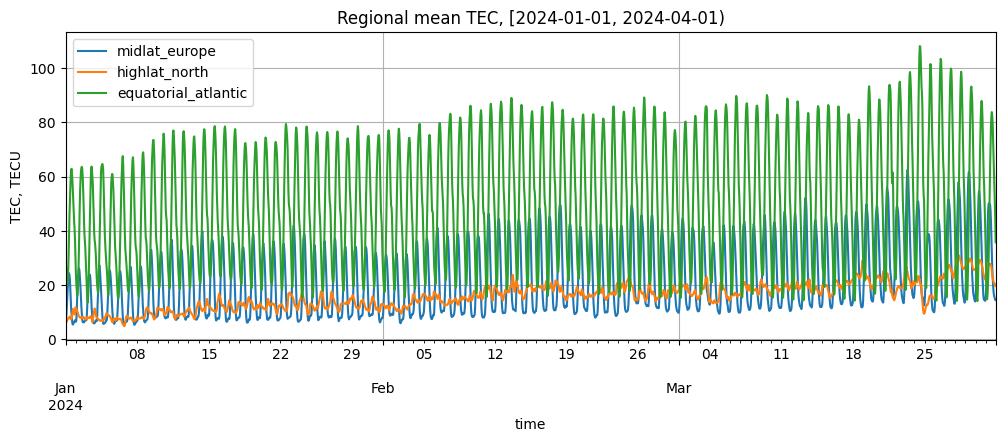

In [13]:

import matplotlib.pyplot as plt

ax = df_regions[["midlat_europe", "highlat_north", "equatorial_atlantic"]].plot(
    figsize=(12, 4),
    grid=True,
    title=f"Regional mean TEC, [{START_DATE}, {END_DATE})",
)
ax.set_ylabel("TEC, TECU")
plt.show()


In [14]:

import json

csv_path = PROCESSED_DIR / f"{OUTPUT_BASENAME}.csv"
parquet_path = PROCESSED_DIR / OUTPUT_FILENAME
meta_path = parquet_path.with_suffix(".meta.json")

df_regions.to_csv(csv_path, index=True)
df_regions.to_parquet(parquet_path)

metadata = {
    "start": START_DATE,
    "end": END_DATE,
    "interval_convention": INTERVAL_CONVENTION,
    "freq": FREQ,
    "n_rows": int(len(df_regions)),
    "regions": list(df_regions.columns),
    "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "source": "CODG IONEX",
    "output_parquet": str(parquet_path),
    "output_csv": str(csv_path),
}

with meta_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved CSV:", csv_path)
print("Saved Parquet:", parquet_path)
print("Saved metadata:", meta_path)

print("CSV size MB:", csv_path.stat().st_size / 1024 / 1024)
print("Parquet size MB:", parquet_path.stat().st_size / 1024 / 1024)
metadata


Saved CSV: /content/drive/MyDrive/tec_agent_project/data/processed/tec_regions_2024_01_01_to_2024_04_01_hourly.csv
Saved Parquet: /content/drive/MyDrive/tec_agent_project/data/processed/tec_regions_2024_01_01_to_2024_04_01_hourly.parquet
Saved metadata: /content/drive/MyDrive/tec_agent_project/data/processed/tec_regions_2024_01_01_to_2024_04_01_hourly.meta.json
CSV size MB: 0.3864622116088867
Parquet size MB: 0.1762065887451172


/tmp/ipykernel_2288/1753557361.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


{'start': '2024-01-01',
 'end': '2024-04-01',
 'interval_convention': '[start, end)',
 'freq': 'hourly',
 'n_rows': 2184,
 'regions': ['equatorial_atlantic',
  'equatorial_africa',
  'equatorial_pacific',
  'midlat_europe',
  'midlat_usa',
  'midlat_asia',
  'midlat_south_america',
  'midlat_australia',
  'highlat_north',
  'highlat_south'],
 'created_at': '2026-05-11T16:05:42Z',
 'source': 'CODG IONEX',
 'output_parquet': '/content/drive/MyDrive/tec_agent_project/data/processed/tec_regions_2024_01_01_to_2024_04_01_hourly.parquet',
 'output_csv': '/content/drive/MyDrive/tec_agent_project/data/processed/tec_regions_2024_01_01_to_2024_04_01_hourly.csv'}

In [15]:
CLEAN_TMP = True

if CLEAN_TMP:
    shutil.rmtree(TMP_DIR, ignore_errors=True)
    print("Temporary raw files removed:", TMP_DIR)
else:
    print("Temporary raw files kept:", TMP_DIR)

Temporary raw files removed: /content/tec_tmp


In [16]:
from tec_agents.data.datasets import register_dataset, get_dataset_summary, get_region_series

register_dataset(
    dataset_ref="default",
    path=parquet_path,
    file_format="parquet",
)

summary = get_dataset_summary("default")
summary

{'dataset_ref': 'default',
 'n_rows': 2184,
 'n_columns': 10,
 'region_columns': ['equatorial_atlantic',
  'equatorial_africa',
  'equatorial_pacific',
  'midlat_europe',
  'midlat_usa',
  'midlat_asia',
  'midlat_south_america',
  'midlat_australia',
  'highlat_north',
  'highlat_south'],
 'start': '2024-01-01 00:00:00',
 'end': '2024-03-31 23:00:00',
 'index_type': 'DatetimeIndex'}

In [17]:
from tec_agents.tools.executor import build_default_executor

executor = build_default_executor(run_id="real_dataset_smoke")

ts_result = executor.call(
    "tec_get_timeseries",
    {
        "dataset_ref": "default",
        "region_id": "midlat_europe",
        "start": "2024-03-01",
        "end": "2024-04-01",
    },
)

threshold_result = executor.call(
    "tec_compute_high_threshold",
    {
        "series_id": ts_result["series_id"],
        "method": "quantile",
        "q": 0.9,
    },
)

intervals_result = executor.call(
    "tec_detect_high_intervals",
    {
        "series_id": ts_result["series_id"],
        "threshold_id": threshold_result["threshold_id"],
        "min_duration_minutes": 0,
        "merge_gap_minutes": 60,
    },
)

print("Threshold:", threshold_result)
print("Intervals:", intervals_result["n_intervals"])
intervals_result["intervals"][:5]

Threshold: {'threshold_id': 'thr_66de044368', 'series_id': 'series_ee29defe20', 'method': 'quantile', 'q': 0.9, 'value': 46.51710743801654, 'n_points_used': 744}
Intervals: 14


[{'start': '2024-03-11 07:00:00',
  'end': '2024-03-11 08:00:00',
  'duration_minutes': 60.0,
  'peak_time': '2024-03-11 08:00:00',
  'peak_value': 47.16363636363637,
  'mean_value': 46.900000000000006,
  'n_points': 2},
 {'start': '2024-03-13 07:00:00',
  'end': '2024-03-13 11:00:00',
  'duration_minutes': 240.0,
  'peak_time': '2024-03-13 09:00:00',
  'peak_value': 52.19008264462811,
  'mean_value': 50.1704132231405,
  'n_points': 5},
 {'start': '2024-03-18 08:00:00',
  'end': '2024-03-18 08:00:00',
  'duration_minutes': 0.0,
  'peak_time': '2024-03-18 08:00:00',
  'peak_value': 47.082644628099175,
  'mean_value': 47.082644628099175,
  'n_points': 1},
 {'start': '2024-03-19 07:00:00',
  'end': '2024-03-19 10:00:00',
  'duration_minutes': 180.0,
  'peak_time': '2024-03-19 08:00:00',
  'peak_value': 49.788429752066115,
  'mean_value': 48.40206611570248,
  'n_points': 4},
 {'start': '2024-03-20 07:00:00',
  'end': '2024-03-20 10:00:00',
  'duration_minutes': 180.0,
  'peak_time': '2024-